<a href="https://colab.research.google.com/github/RayaneRahmatErrahmaneSMARA/elevvoInternship/blob/main/Loan_Approval_Prediction_Description.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
# CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)
from imblearn.over_sampling import SMOTE

%matplotlib inline
plt.style.use('seaborn-v0_8')

In [72]:
# CELL 2: Load Data
url = "https://gist.githubusercontent.com/Nwaneto/44c4743cd97b8fb44fed5330cfb637a4/raw/loan-prediction-dataset.csv"
df = pd.read_csv(url)

print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [73]:
# CELL 3: Initial Exploration & Missing Values
print("Missing Values:")
display(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe(include='all'))

Missing Values:


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



Basic Statistics:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [74]:
# CELL 4: Handle Missing Values
# Numerical → median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [75]:
# CELL 5: Train-Test Split (before any preprocessing to avoid leakage)
target = "Loan_Status"
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (491, 12), Test shape: (123, 12)


In [76]:
# CELL 6: Encode Target Variable (for metrics that require numeric labels)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)    # 'N' → 0, 'Y' → 1
y_test_enc  = le.transform(y_test)

print("Target mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Target mapping: {'N': np.int64(0), 'Y': np.int64(1)}


In [77]:
# CELL 7: Preprocessing Pipeline Setup
# Drop Loan_ID if present (not useful for modeling)
if 'Loan_ID' in X_train.columns:
    X_train = X_train.drop('Loan_ID', axis=1)
    X_test  = X_test.drop('Loan_ID', axis=1)

numerical_cols   = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [78]:
# CELL 8: Apply Preprocessing + SMOTE
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed  = preprocessor.transform(X_test)

# Handle class imbalance with SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preprocessed, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution before SMOTE:
Loan_Status
Y    337
N    154
Name: count, dtype: int64

Class distribution after SMOTE:
Loan_Status
Y    337
N    337
Name: count, dtype: int64


In [79]:
# CELL 9: Train Models
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)

print("Models trained successfully!")

Models trained successfully!


In [80]:
# CELL 10: Predictions
y_pred_lr = log_reg.predict(X_test_preprocessed)
y_pred_dt = dt.predict(X_test_preprocessed)

# Convert string predictions back to numeric for evaluation
y_pred_lr_enc = le.transform(y_pred_lr)
y_pred_dt_enc = le.transform(y_pred_dt)

In [81]:
# CELL 11: Evaluation Metrics
print("=== Logistic Regression ===")
print(classification_report(y_test_enc, y_pred_lr_enc, target_names=['N', 'Y']))
print("Accuracy:", accuracy_score(y_test_enc, y_pred_lr_enc))
print()

print("=== Decision Tree ===")
print(classification_report(y_test_enc, y_pred_dt_enc, target_names=['N', 'Y']))
print("Accuracy:", accuracy_score(y_test_enc, y_pred_dt_enc))

=== Logistic Regression ===
              precision    recall  f1-score   support

           N       0.71      0.66      0.68        38
           Y       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123

Accuracy: 0.8130081300813008

=== Decision Tree ===
              precision    recall  f1-score   support

           N       0.67      0.53      0.59        38
           Y       0.81      0.88      0.84        85

    accuracy                           0.77       123
   macro avg       0.74      0.70      0.72       123
weighted avg       0.76      0.77      0.76       123

Accuracy: 0.7723577235772358


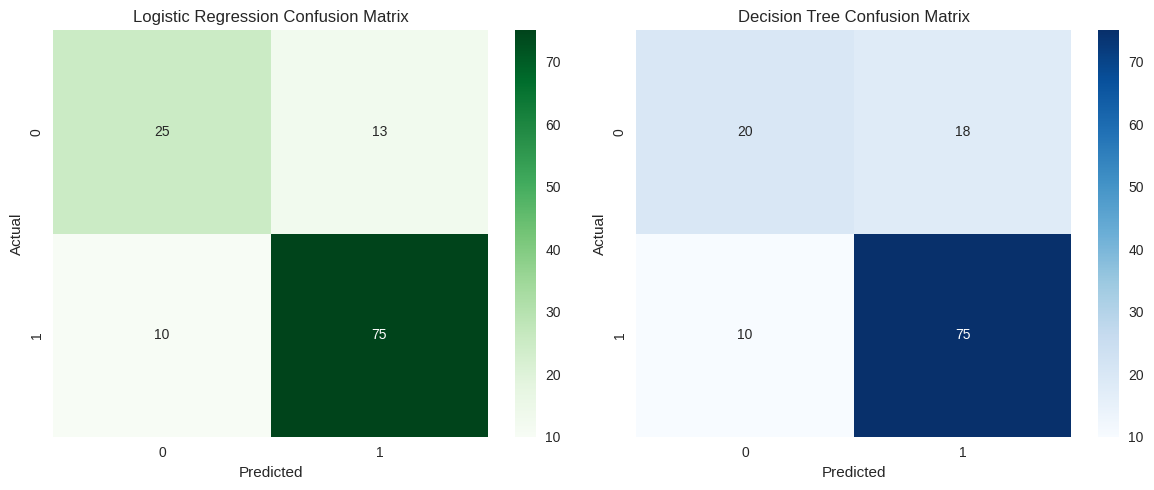

In [82]:
# CELL 12: Confusion Matrices (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test_enc, y_pred_lr_enc), annot=True, fmt='d',
            cmap='Greens', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_enc, y_pred_dt_enc), annot=True, fmt='d',
            cmap='Blues', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

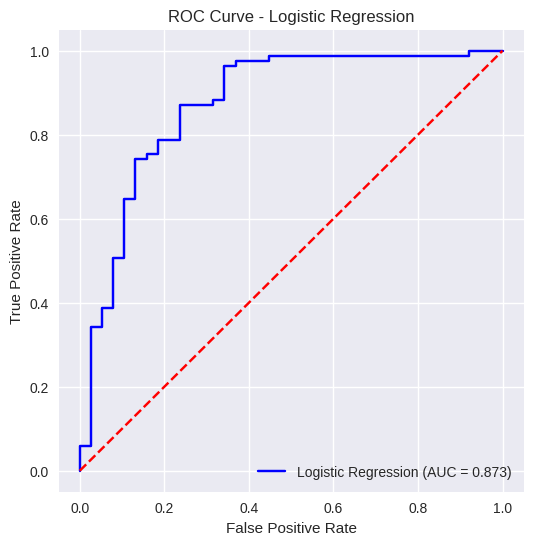

In [83]:
# CELL 13: ROC Curve (Logistic Regression)
y_probs_lr = log_reg.predict_proba(X_test_preprocessed)[:, 1]
fpr, tpr, _ = roc_curve(y_test_enc, y_probs_lr)
auc_score = roc_auc_score(y_test_enc, y_probs_lr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.3f})', color='blue')
plt.plot([0,1], [0,1], '--', color='red')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

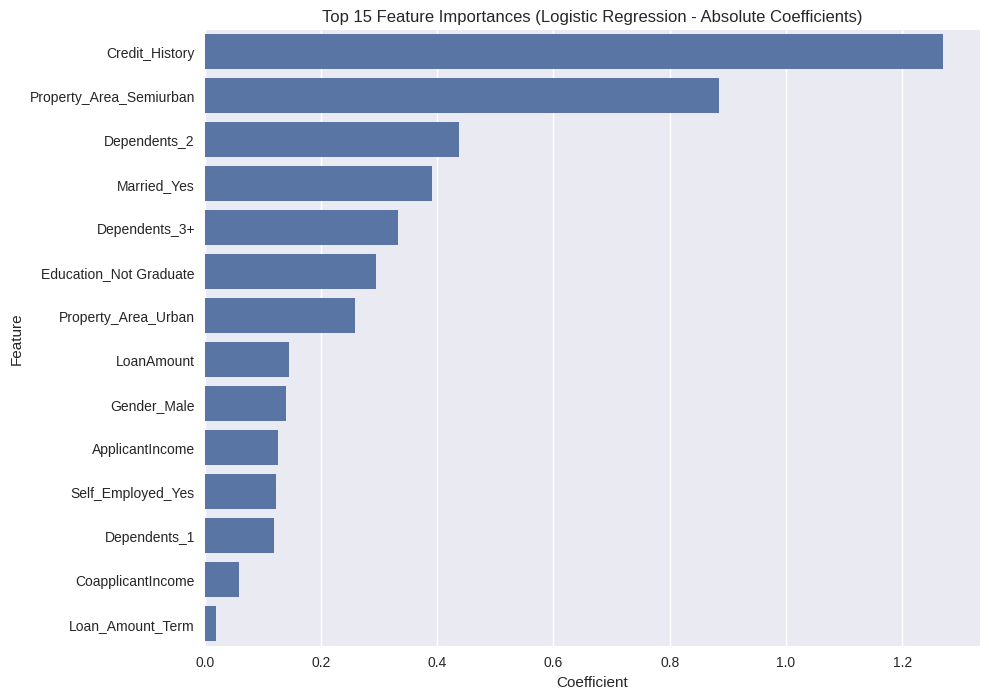

In [84]:
# CELL 14: Feature Importance - Logistic Regression (Coefficients)
def get_feature_names(preprocessor):
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            feature_names.extend(transformer.get_feature_names_out(cols))
    return feature_names

feature_names = get_feature_names(preprocessor)
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': abs(log_reg.coef_[0])  # absolute value for importance
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(15))
plt.title('Top 15 Feature Importances (Logistic Regression - Absolute Coefficients)')
plt.show()

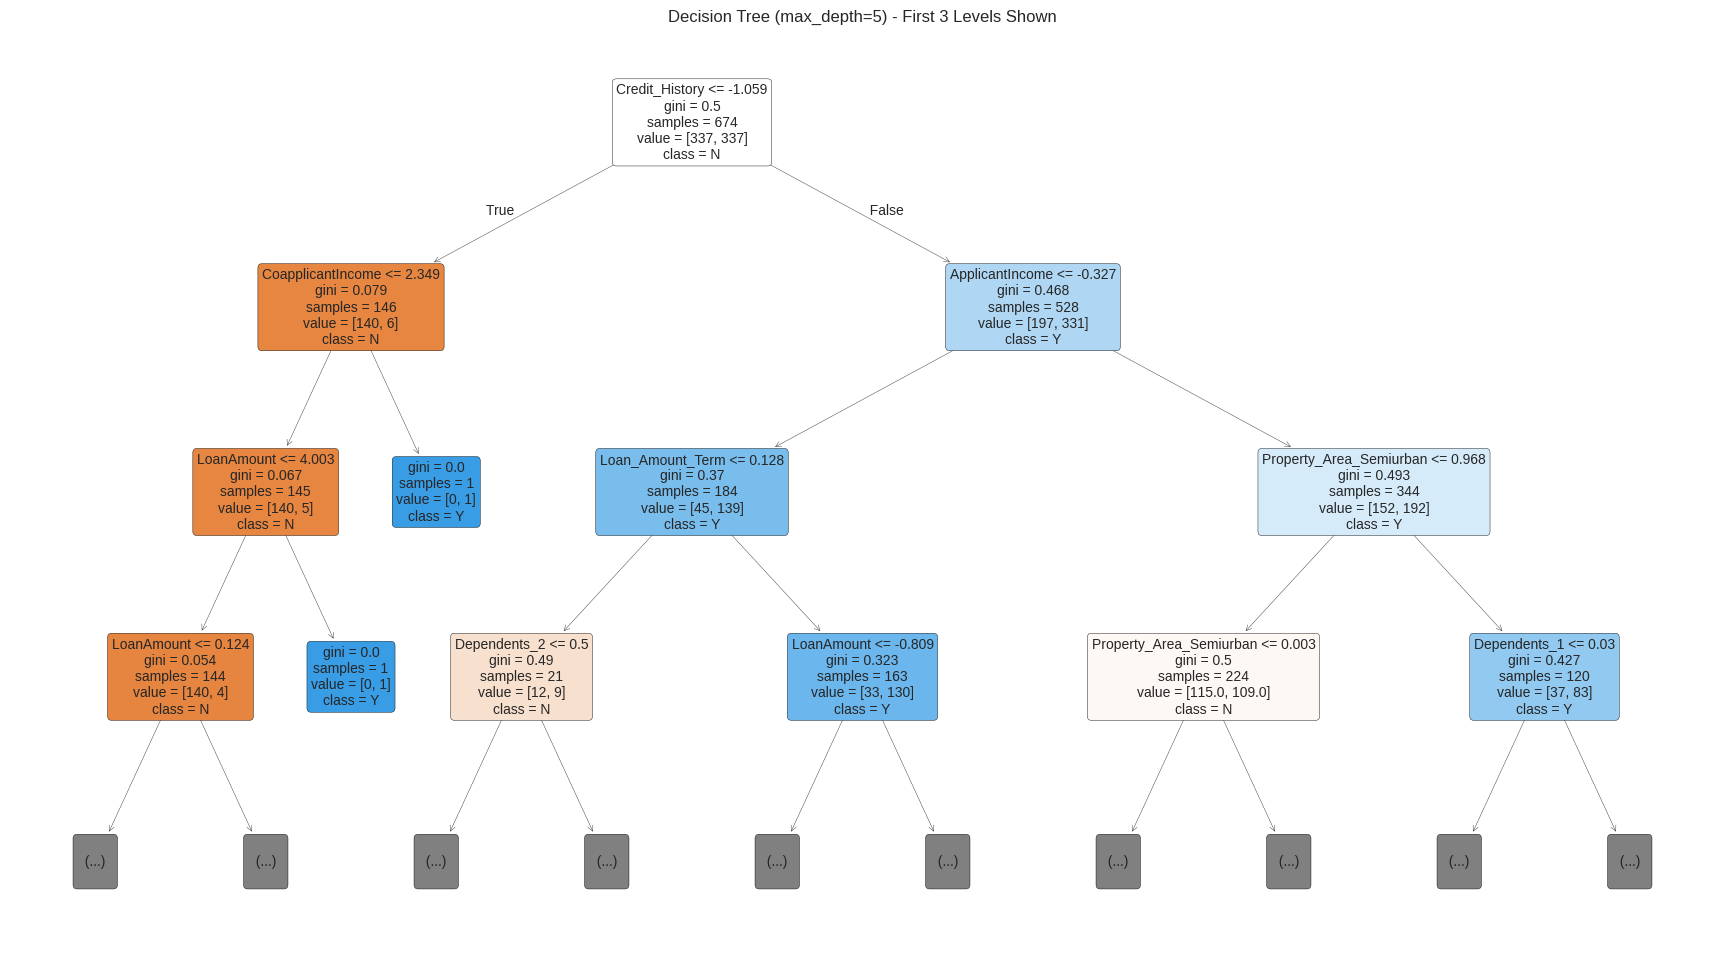

In [85]:
# CELL 15: Decision Tree Visualization
plt.figure(figsize=(22, 12))
plot_tree(dt, feature_names=feature_names, class_names=['N', 'Y'],
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Decision Tree (max_depth=5) - First 3 Levels Shown')
plt.show()

In [86]:
# CELL 16: Final Conclusion
print("="*50)
print("           FINAL MODEL COMPARISON")
print("="*50)

lr_acc = accuracy_score(y_test_enc, y_pred_lr_enc)
dt_acc = accuracy_score(y_test_enc, y_pred_dt_enc)

print(f"Logistic Regression Accuracy : {lr_acc:.3f}")
print(f"Decision Tree Accuracy       : {dt_acc:.3f}")
print()
print("Conclusion:")
print("• Logistic Regression outperforms Decision Tree in accuracy, precision, and F1-score.")
print("• Both models have similar recall — good at identifying approved loans.")
print("• Logistic Regression is recommended for better overall predictive performance.")
print("• Decision Tree offers interpretability (rules are easy to extract).")
print("• Consider trying Random Forest or XGBoost for potential further improvements.")
print("="*50)

           FINAL MODEL COMPARISON
Logistic Regression Accuracy : 0.813
Decision Tree Accuracy       : 0.772

Conclusion:
• Logistic Regression outperforms Decision Tree in accuracy, precision, and F1-score.
• Both models have similar recall — good at identifying approved loans.
• Logistic Regression is recommended for better overall predictive performance.
• Decision Tree offers interpretability (rules are easy to extract).
• Consider trying Random Forest or XGBoost for potential further improvements.
